# DAI Mission — Proposal
**Data & AI in Economics | TU Dortmund**

## 1. Team

| Role | Name | 
|------|------|
| Lead | Mariia Hrechyn| 
| Member | Lutz Weiland | 

## 2. Mission Title & Research Question

**Title:** *From Balance Sheets to Buy Signals: Causal, Supervised, and Unsupervised Analysis of Fundamental Stock Return Prediction*

**Research question:**  
*Can fundamental financial ratios derived from income statements, balance sheets, and cash-flow statements reliably predict 1-year stock return direction (buy / hold / sell) for US-listed firms? 
Specifically: 

- (i) which latent fundamental profiles (clusters) carry the most predictive information, 
- (ii) does profitability (ROE) causally drive future return class after controlling for sector, leverage, size, book-to-market, and investment growth, and 
- (iii) do ensemble classifiers outperform a **Fama-French 5-factor (FF5)** economic baseline because they learn stronger class-specific signals from accounting variables, or because they better resolve uncertainty in the ambiguous hold class?*

**Why it matters:**  
*Fundamental analysis is central to active investment management, yet it is rarely subjected to rigorous causal scrutiny — most ML studies on financial data report predictive correlations without separating genuine economic drivers from sector-level confounders. This project applies three complementary lenses to a self-constructed dataset of US public-company fundamentals (SimFin, CC BY-NC 4.0): unsupervised clustering to discover latent firm archetypes, causal inference to distinguish structural profitability drivers from correlates, and supervised classification benchmarked against the Fama-French 5-factor model. Requiring all three lenses to inform each other tests whether data-driven fundamental analysis adds genuine economic value beyond established factor heuristics, or merely re-packages known market risks in a more complex form.*

## 3. Data

**Primary Source:** SimFin — Fundamental Financial Data for US-listed Companies  
Provider: SimFin ApS (Denmark)  
Access: https://simfin.com/data/access/api (free tier, Python package `simfin`)  
Licence: **CC BY-NC 4.0** — free for academic use with attribution.

---

### 3a. Raw Dataset Retrieved (`simfin_data_retrieval.ipynb`)

The data retrieval script (`simfin_data_retrieval.ipynb`) fetches all available annual US fundamentals from the SimFin API and merges them into a single panel. The raw panel saved as `simfin_raw_panel.csv` has the following characteristics:

| Property | Value |
|----------:|-------|
| Rows (company × fiscal-year) | **18,088** |
| Columns (raw features + metadata) | **86+** |
| Unique tickers | **4,787** |
| Fiscal years covered | **2020 – 2024** |
| Currency filter | USD only |
| Statement types merged | Income statement (standard / bank / insurance), Balance sheet, Cash-flow statement |

---

### 3b. Target Variable Construction

**Step 1 — 1-year forward total return (`Perform`)**  

```
Perform = (Price_{t+252} − Price_{t}) / Price_{t}
```

Observations where either price is unavailable are left as `NaN` and excluded from modelling. This yields **13,601 non-null return observations** out of 18,088 total.

**Step 2 — Ternary class label (`Class`) —  Calendar-Quarter Cohort Labeling**


| Class | Label | Meaning |
|------:|-------|--------|
| **−1** | Sell | Bottom tercile within calendar-quarter cohort |
| **0** | Hold | Middle tercile |
| **+1** | Buy | Top tercile |

---

### 3c. Pre-processing Plan (`data_preprocessing.ipynb`)


**Temporal split:**

| Partition | Fiscal Years | Purpose |
|-----------|-------------|--------|
| Training | FY 2020–2022 | Model fitting, imputation statistics |
| Validation | FY 2023 | Hyperparameter tuning |
| Test (holdout) | FY 2024 | Final evaluation |

1. **Missing value inspection** — Per-column missing rates; columns > 50% missing dropped.
2. **Sector-median imputation** — Fit on training only; frozen and applied to all splits.
3. **Winsorisation** — 1st–99th percentile bounds from training only.
4. **Z-score standardisation** — Mean and std from training only.

---

**Derived financial ratios** (winsorised at 1st–99th pct; training-set bounds):

| Ratio | Formula | Role |
|-------|---------|------|
| `ROE` | `Net Income (Common)` / `Total Equity` | **Causal treatment** — equity profitability |
| `ROA` | `Net Income` / `Total Assets` | Feature — asset profitability |
| `Leverage` | `Total Liabilities` / `Total Equity` | **Confounder** — financial risk |
| `GrossMargin` | `Gross Profit` / `Revenue` | Feature — pricing power |
| `OperatingMargin` | `Operating Income (Loss)` / `Revenue` | Feature — operational efficiency |
| `CurrentRatio` | `Total Current Assets` / `Total Current Liabilities` | Feature — short-term liquidity |
| `DebtRatio` | `Total Liabilities` / `Total Assets` | Feature — solvency |
| `CFO_Margin` | `Net Cash from Operating Activities` / `Revenue` | Feature — cash generation quality |
| `Size` | `log(MarketCap)` | **Confounder (SMB proxy)** — firm size |
| `BookToMarket` | `Total Equity / MarketCap` | **Confounder (HML proxy)** — value factor |
| `InvestmentGrowth` | YoY % change in `Total Assets` | **Confounder (CMA proxy)** — investment factor |

---

**Potential data quality issues:**


- **Missing values:** Handled via training-set sector-median imputation; columns > 50% missing dropped.
- **Extreme outliers:** Winsorisation at 1st–99th percentile (training-set bounds only).
- **Macro anomalies:** COVID-19 (2020) and rate-hiking cycle (2022) are anomalous macro periods. Controlled via NBER recession indicator feature and year-fixed effects in causal models.

---

**Income Statement columns** (`fin_type`)

| Column | Type | Role |
|--------|------|------|
| `Revenue` | Continuous | Feature / ratio denominator |
| `Cost of Revenue` | Continuous | Feature — direct production costs |
| `Gross Profit` | Continuous | Feature / GrossMargin numerator |
| `Operating Expenses` | Continuous | Feature — overhead burden |
| `Selling, General & Administrative` | Continuous | Feature — overhead spending |
| `Operating Income (Loss)` | Continuous | Feature / OperatingMargin numerator |
| `Non-Operating Income (Loss)` | Continuous | Feature — one-off gains/losses |
| `Interest Expense, Net` | Continuous | Feature — cost of debt financing |
| `Pretax Income (Loss), Adj.` | Continuous | Feature — adjusted earnings before tax |
| `Abnormal Gains (Losses)` | Continuous | Feature — earnings quality signal |
| `Pretax Income (Loss)` | Continuous | Feature — earnings before tax |
| `Income Tax (Expense) Benefit, Net` | Continuous | Feature — tax charge |
| `Income (Loss) from Continuing Operations` | Continuous | Feature — profit from ongoing business |
| `Net Income` | Continuous | Feature / ROA numerator |
| `Net Income (Common)` | Continuous | Feature / **ROE numerator** |

**Balance Sheet columns** (`fin_type_bal`)

| Column | Type | Role |
|--------|------|------|
| `Cash, Cash Equivalents & Short Term Investments` | Continuous | Feature — liquidity buffer |
| `Accounts & Notes Receivable` | Continuous | Feature — uncollected revenue |
| `Inventories` | Continuous | Feature — goods held for sale |
| `Total Current Assets` | Continuous | Feature / CurrentRatio numerator |
| `Property, Plant & Equipment, Net` | Continuous | Feature — long-term physical assets |
| `Other Long Term Assets` | Continuous | Feature — intangibles, deferred taxes |
| `Total Noncurrent Assets` | Continuous | Feature — total long-term asset base |
| `Total Assets` | Continuous | Feature / ROA & DebtRatio denominator |
| `Payables & Accruals` | Continuous | Feature — obligations to suppliers |
| `Short Term Debt` | Continuous | Feature — debt maturing within one year |
| `Total Current Liabilities` | Continuous | Feature / CurrentRatio denominator |
| `Long Term Debt` | Continuous | **Confounder** — leverage proxy in the causal DAG |
| `Total Noncurrent Liabilities` | Continuous | Feature — long-term obligations |
| `Total Liabilities` | Continuous | Feature / Leverage & DebtRatio numerator |
| `Share Capital & Additional Paid-In Capital` | Continuous | Feature — equity raised from shareholders |
| `Retained Earnings` | Continuous | Feature — accumulated past profits |
| `Total Equity` | Continuous | Feature / **ROE & Leverage denominator** |
| `Total Liabilities & Equity` | Continuous | Feature — balance check |

**Cash-Flow Statement columns** (`fin_type_cf`)

| Column | Type | Role |
|--------|------|------|
| `Net Income/Starting Line` | Continuous | Feature — accrual profit starting point |
| `Depreciation & Amortization_cf` | Continuous | Feature — non-cash add-back |
| `Non-Cash Items` | Continuous | Feature — stock-based compensation |
| `Change in Working Capital` | Continuous | Feature — accruals quality signal |
| `Net Cash from Operating Activities` | Continuous | Feature / **CFO_Margin numerator** |
| `Change in Fixed Assets & Intangibles` | Continuous | Feature — capex proxy |
| `Net Cash from Investing Activities` | Continuous | Feature — net capital deployed |
| `Cash from (Repayment of) Debt` | Continuous | Feature — debt financing activity |
| `Cash from (Repurchase of) Equity` | Continuous | Feature — share buybacks/issuance |
| `Net Cash from Financing Activities` | Continuous | Feature — net capital raised |
| `Net Change in Cash` | Continuous | Feature — end-to-end liquidity change |

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Load cleaned & imputed dataset ──────────────────────────────────────────
df_raw = pd.read_csv('simfin_cleaned_imputed.csv')

# Keep only rows where Class and Perform are available
df = df_raw[df_raw['Class'].notna() & df_raw['Perform'].notna()].copy()
df['Class'] = df['Class'].astype(int)

print(f'Dataset shape: {df.shape}')
print(f'Unique tickers: {df["Ticker"].nunique()}')
print(f'Fiscal years: {sorted(df["FiscalYear"].unique())}')
df.head(3)

Dataset shape: (13601, 61)
Unique tickers: 4309
Fiscal years: [2020, 2021, 2022, 2023, 2024]


,Ticker,Report Date,Fiscal Year,Revenue,Cost of Revenue,Gross Profit,Operating Expenses,"Selling, General & Administrative",Operating Income (Loss),Non-Operating Income (Loss),...,fin_type_cf,Company Name,IndustryId,Sector,Industry,Market,Main Currency,Perform,FiscalYear,Class
0,A,2020-10-31,2020.0,5.339000e+09,-2.502000e+09,2.837000e+09,-1.991000e+09,-1.496000e+09,8.460000e+08,-4000000.0,...,standard,AGILENT TECHNOLOGIES INC,106001.0,Healthcare,Medical Diagnostics & Research,us,USD,0.427021,2020,1
1,A,2021-10-31,2021.0,6.319000e+09,-2.912000e+09,3.407000e+09,-2.060000e+09,-1.619000e+09,1.347000e+09,13000000.0,...,standard,AGILENT TECHNOLOGIES INC,106001.0,Healthcare,Medical Diagnostics & Research,us,USD,-0.212426,2021,0
2,A,2022-10-31,2022.0,6.848000e+09,-3.126000e+09,3.722000e+09,-2.104000e+09,-1.637000e+09,1.618000e+09,-114000000.0,...,standard,AGILENT TECHNOLOGIES INC,106001.0,Healthcare,Medical Diagnostics & Research,us,USD,-0.140251,2022,-1


In [4]:
# ── Derive financial ratios ──────────────────────────────────────────────────
def safe_div(a, b):
    '''Division robust to zero denominators.'''
    return a / b.replace(0, np.nan)

df['ROE']             = safe_div(df['Net Income (Common)'],              df['Total Equity'])
df['ROA']             = safe_div(df['Net Income'],                       df['Total Assets'])
df['Leverage']        = safe_div(df['Total Liabilities'],                df['Total Equity'])
df['GrossMargin']     = safe_div(df['Gross Profit'],                     df['Revenue'])
df['OperatingMargin'] = safe_div(df['Operating Income (Loss)'],          df['Revenue'])
df['CurrentRatio']    = safe_div(df['Total Current Assets'],             df['Total Current Liabilities'])
df['DebtRatio']       = safe_div(df['Total Liabilities'],                df['Total Assets'])
df['CFO_Margin']      = safe_div(df['Net Cash from Operating Activities'], df['Revenue'])

# Rev 4 confounders — include if present from updated retrieval script
NEW_CONFOUNDER_COLS = [c for c in ['Size', 'BookToMarket', 'InvestmentGrowth']
                       if c in df.columns]
BASE_RATIO_COLS = ['ROE', 'ROA', 'Leverage', 'GrossMargin',
                   'OperatingMargin', 'CurrentRatio', 'DebtRatio', 'CFO_Margin']
RATIO_COLS = BASE_RATIO_COLS + NEW_CONFOUNDER_COLS
print(f'Ratio columns: {RATIO_COLS}')

# Bounds computed on TRAINING partition only (FY2020-2022).
# Using full dataset to compute percentiles leaks val/test information.
TRAIN_YEARS = [2020, 2021, 2022]
VAL_YEARS   = [2023]
TEST_YEARS  = [2024]
train_mask  = df['FiscalYear'].isin(TRAIN_YEARS)

winsor_bounds = {}
for col in RATIO_COLS:
    if col not in df.columns: continue
    lo = df.loc[train_mask, col].quantile(0.01)
    hi = df.loc[train_mask, col].quantile(0.99)
    df[col] = df[col].clip(lo, hi)
    winsor_bounds[col] = (lo, hi)

print('Winsorised ratios using TRAINING-SET bounds (FY2020-2022):')
df[RATIO_COLS].describe().round(3)

Ratio columns: ['ROE', 'ROA', 'Leverage', 'GrossMargin', 'OperatingMargin', 'CurrentRatio', 'DebtRatio', 'CFO_Margin']
Winsorised ratios using TRAINING-SET bounds (FY2020-2022):


,ROE,ROA,Leverage,GrossMargin,OperatingMargin,CurrentRatio,DebtRatio,CFO_Margin
count,13601.000,13601.000,13601.000,13593.000,13593.000,13601.000,13601.000,13593.000
mean,-0.122,-0.116,1.933,4.852,-2.534,4.005,0.588,-2.010
std,1.258,0.396,5.395,28.674,13.496,6.195,0.398,11.158
min,-7.823,-2.381,-22.124,-0.366,-107.071,0.051,0.030,-90.477
25%,-0.218,-0.133,0.333,0.271,-0.182,1.226,0.333,-0.087
50%,0.043,0.009,1.006,0.493,0.052,2.156,0.553,0.078
75%,0.160,0.058,2.340,0.791,0.175,3.706,0.765,0.210
max,4.802,0.364,31.457,252.762,0.754,43.554,2.671,1.244


Columns with any missing values: 5

Missing-rate table:
                 missing_rate
IndustryId             0.0029
Fiscal Year            0.0011
OperatingMargin        0.0006
GrossMargin            0.0006
CFO_Margin             0.0006


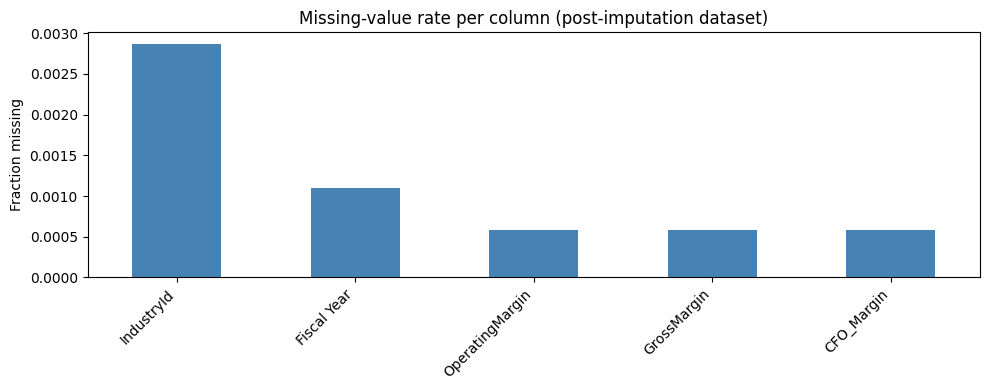

In [5]:
# ── Missing values overview ──────────────────────────────────────────────────
num_cols = df.select_dtypes(include='number').columns.tolist()
miss = df[num_cols].isnull().mean().sort_values(ascending=False)
miss = miss[miss > 0]

print(f'Columns with any missing values: {len(miss)}')
print('\nMissing-rate table:')
print(miss.to_frame('missing_rate').round(4))

if len(miss) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    colors = ['red' if v > 0.5 else 'orange' if v > 0.1 else 'steelblue' for v in miss.values]
    miss.plot(kind='bar', color=colors, ax=ax)
    ax.set_title('Missing-value rate per column (post-imputation dataset)')
    ax.set_ylabel('Fraction missing')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No missing values remain in numeric columns.')

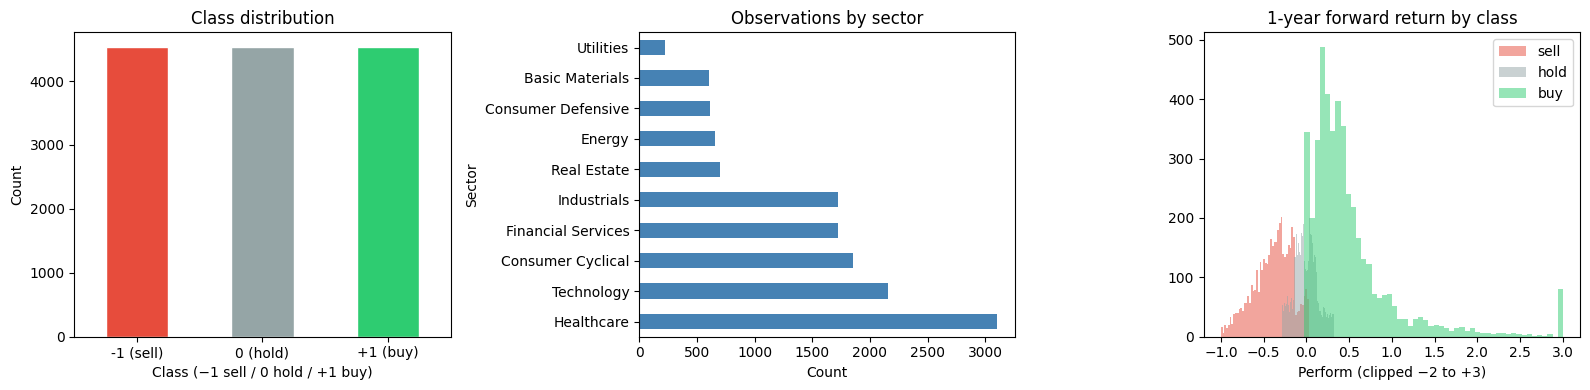

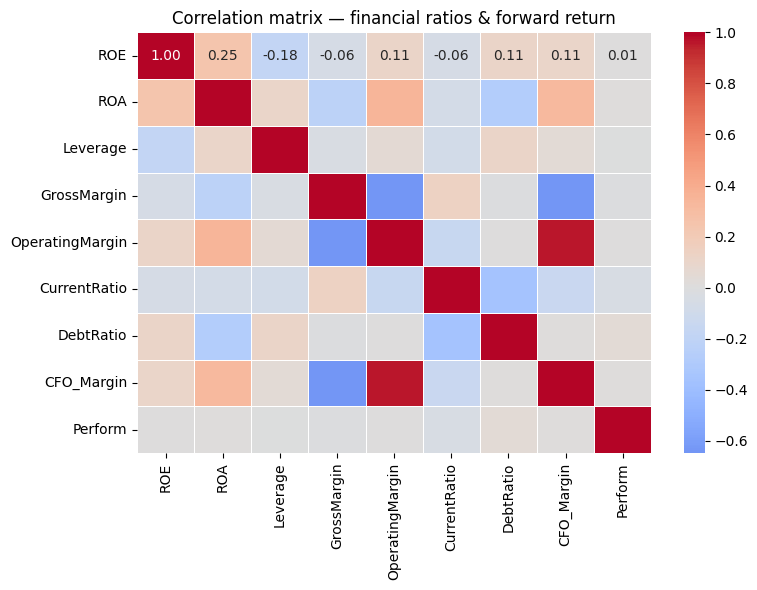

In [6]:
# ── EDA: Class distribution, Sector breakdown, Ratio correlations ────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

class_counts = df['Class'].value_counts().sort_index()
class_counts.plot(kind='bar', ax=axes[0], color=['#e74c3c','#95a5a6','#2ecc71'], edgecolor='white')
axes[0].set_title('Class distribution')
axes[0].set_xlabel('Class (−1 sell / 0 hold / +1 buy)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['-1 (sell)', '0 (hold)', '+1 (buy)'], rotation=0)

sector_counts = df['Sector'].value_counts().head(10)
sector_counts.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Observations by sector')
axes[1].set_xlabel('Count')

for cls, color, label in [(-1,'#e74c3c','sell'), (0,'#95a5a6','hold'), (1,'#2ecc71','buy')]:
    axes[2].hist(df.loc[df['Class']==cls, 'Perform'].clip(-2, 3), bins=50, alpha=0.5, color=color, label=label)
axes[2].set_title('1-year forward return by class')
axes[2].set_xlabel('Perform (clipped −2 to +3)')
axes[2].legend()
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 6))
corr = df[RATIO_COLS + ['Perform']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax2, linewidths=0.5)
ax2.set_title('Correlation matrix — financial ratios & forward return')
plt.tight_layout()
plt.show()

## 4. Planned Methods

The mission applies at least one technique from each of the three mandatory blocks. Ticked items below are the methods we plan to use; each choice is justified in terms of the research question and dataset properties.


### 4a. Causal Inference

- [x] **Causal graph / DAG (DoWhy)**
- [x] **Backdoor adjustment**
- [ ] Instrumental variable
- [x] **Propensity score stratification** (robustness check)

*Justification:*  
We ask whether high return-on-equity (ROE) *causally* increases the probability of a buy signal after controlling for well-established financial confounders. A DAG is the minimal formal structure required to state that assumption precisely and to identify a valid adjustment set.


**DAG structure:**

```
Size             ──→ ROE,  FwdReturn
BookToMarket     ──→ ROE,  FwdReturn
InvestmentGrowth ──→ ROE,  FwdReturn
Leverage         ──→ ROE,  FwdReturn
Sector           ──→ ROE,  FwdReturn
ROE              ──→ FwdReturn        ← path of interest (ATE)
```

**Edge rationale:**
- *Size → ROE*: larger firms face more competitive pressure on margins; size mechanically scales equity.
- *Size → FwdReturn*: Fama-French SMB factor — small firms earn a return premium.
- *BookToMarket → ROE*: high book-to-market (value) firms tend to have lower profitability.
- *BookToMarket → FwdReturn*: Fama-French HML value premium.
- *InvestmentGrowth → ROE*: rapid asset accumulation dilutes asset productivity ratios.
- *InvestmentGrowth → FwdReturn*: Fama-French CMA factor — conservative firms earn higher returns.
- *Leverage → ROE*: DuPont identity — leverage amplifies ROE mechanically.
- *Leverage → FwdReturn*: financial distress risk premium.
- *Sector → ROE, FwdReturn*: industry-level capital structure norms and return differentials.
- *ROE → FwdReturn*: our causal hypothesis.

**Identification:** backdoor adjustment on {Size, BookToMarket, InvestmentGrowth, Leverage, Sector} blocks all confounding paths into ROE and satisfies the backdoor criterion.

**Estimation methods:**
- Primary: propensity-score stratification (ROE tercile as treatment level)
- Robustness: doubly-robust AIPW estimator

**Validation:** ≥ 2 DoWhy refutation tests — `add_unobserved_common_cause` and `placebo_treatment_refuter`.

**Synthesis with other blocks:** If RF/XGBoost feature importances rank ROE, Size, and BookToMarket as top predictors, this is consistent with the causal DAG. A small causal ATE alongside high supervised feature importance signals a largely correlational relationship — discussed explicitly in Section 8.

### 4b. Supervised Learning

- [ ] Linear / Ridge / Lasso regression
- [x] **Logistic regression** (Softmax / multinomial, used in the Soft Voting Ensemble)
- [ ] k-Nearest Neighbors
- [ ] Support Vector Machine
- [x] **Decision Tree / Random Forest** (primary interpretable model; feature importances)
- [ ] Neural network
- [x] **Other:** XGBoost (gradient boosting), Soft Voting Ensemble (RF + XGBoost + Softmax)

*Justification:*  
The task is ternary classification (sell / hold / buy) on structured tabular data with mixed ratio and categorical features. Ensemble tree models (RF, XGBoost) are the established best practice for this data type: they handle non-linear interactions, are robust to outlier ratios, and require no feature scaling.

**Feature set:** 8 derived financial ratios + Size, BookToMarket, InvestmentGrowth (FF5 factor proxies) + NBER recession indicator + Sector dummies + Cluster membership from Section 4c.

**Temporal split:** train FY2020–2022 (NBER recession flag absorbs COVID anomaly), validate FY2023, test FY2024. All imputation / winsorisation / standardisation statistics computed on training set only.

> **Fama-French 5-Factor (FF5) Economic Baseline:**  
> The original proposal used FF3. FF3 is outdated for profitability research because it excludes the profitability (RMW) and investment (CMA) factors — directly related to the accounting-ratio features used here. Using FF3 would risk falsely attributing factor exposure to ML "skill". We upgrade to **FF5 (Fama & French, 2015)**.

**FF5 baseline procedure:**  
Monthly FF5 factors (MKT, SMB, HML, RMW, CMA) downloaded from the Kenneth French Data Library. For each firm, a trailing 12-month regression is fit:

```
R_i,t − R_f,t = α_i + β₁·MKT + β₂·SMB + β₃·HML + β₄·RMW + β₅·CMA + ε
```

Predicted excess return converted to directional class label using the same calendar-quarter cohort tercile rule as the target.

**Long-Short portfolio alpha:**  
At each calendar-quarter rebalancing date, form Long (Buy-signal) and Short (Sell-signal) equal-weighted portfolios. Regress spread returns on FF5 factors; the **FF5 alpha** is the return unexplained by the five factors. Report annualised alpha, t-statistic, and Sharpe ratio.

**Synthesis with unsupervised block:** Cluster membership from Section 4c is a supervised feature. Ablation study measures the marginal information contribution.

### 4c. Unsupervised / Generative Learning

- [x] **K-Means clustering** (segment firms into latent fundamental archetypes)
- [x] **Hierarchical clustering** (Ward linkage; dendrogram to validate k independently of K-Means)
- [ ] Variational autoencoder
- [ ] GAN
- [x] **Other:** PCA (dimensionality reduction before clustering)

*Justification:*  
The 8+ financial ratios are strongly collinear (ROE and ROA both capture profitability; Leverage and DebtRatio both capture solvency). PCA decorrelates them and projects firms into a low-dimensional fundamental space where K-Means distance metrics are more stable and interpretable. Hierarchical clustering (Ward) cross-validates the number of natural clusters via dendrogram without requiring a pre-specified k.

**Synthesis with supervised block:** The cluster label is added as a categorical feature to the supervised classifier (Section 4b). An ablation study measures the marginal information contribution of cluster membership.

**Synthesis with causal block:** If high-ROE firms cluster into a distinct 'quality' archetype, the causal ATE of ROE on Buy should be largest within that cluster — providing a consistency check on the DAG structural assumptions.

## 5. Evaluation Strategy

**Supervised learning metrics:**  
Per-class precision, recall, and F1-score (macro-averaged) as the primary statistical metric. Directional accuracy as the primary economic metric. AUC-OVR for probability calibration. All reported on the temporal hold-out set (FY2024).

**Economic baselines:**
- *Majority-class baseline:* always predict the most frequent class.
- *Random baseline:* uniform random prediction.
- *Fama-French 5-factor (FF5) baseline:* use FF5, which explicitly captures profitability (RMW) and investment (CMA) effects directly related to the accounting ratios used as features. 
- *Long-Short portfolio alpha:* annualised FF5 alpha of the Long-Buy / Short-Sell spread, with t-statistic and Sharpe ratio. Provides an economically interpretable value-add measure beyond factor exposure.

**Causal validation:**  
≥ 2 DoWhy refutation tests: `add_unobserved_common_cause` (sensitivity to hidden confounders) and `placebo_treatment_refuter` (should yield near-zero ATE).

**Unsupervised evaluation:**  
Silhouette score across k = 2–8; elbow criterion on inertia; economic profiling of clusters; ablation study with/without Cluster features.

**Survivorship bias robustness:**  
The SimFin free tier covers only currently-listed US firms; bankrupt or delisted firms are absent. Two bias mechanisms affect training: (a) *feature-level* — the model learns characteristics of survivors, not ex-ante selections; (b) *return-level* — the left tail of the return distribution is truncated, inflating Buy-signal apparent performance (Banz, 1981; Kothari et al., 1995). We quantify severity by comparing SimFin universe counts per year against Compustat/CRSP benchmarks. All performance claims are explicitly qualified with this caveat.

**Synthesis criterion:**  
(1) PCA/K-Means cluster profiles → feature engineering for the supervised block; (2) supervised feature importances → consistency check on the causal DAG; (3) causal ATE vs. supervised performance → distinguishes structural drivers from correlates; (4) ML vs. FF5 + Long-Short alpha → economic value-add.

## 6. Work Plan

| # | Task | Owner | Deliverable |
|---|------|-------|-------------|
| 1 | Data retrieval — SimFin fundamentals + prices; forward returns; calendar-quarter cohort class labels; NBER recession flag; Size/BtM/InvestmentGrowth | Mariia | `simfin_data_retrieval.ipynb`, `simfin_dataset.csv` |
| 2 | Data cleaning & imputation — drop high-missing columns; training-set sector-median imputation; leakage-free winsorisation & z-score | Lutz | `data_preprocessing.ipynb`, `simfin_cleaned_imputed.csv` |
| 3 | EDA & ratio derivation — derive 8 financial ratios + 3 FF5 proxies; class/sector/return distribution plots; correlation heatmap | Mariia | Executed cells in proposal (Section 3) |
| 4 | Unsupervised block — z-score scaling, PCA (≥80% variance), k-means (elbow + silhouette), Ward hierarchical clustering, cluster profiling | Mariia | Section 7c |
| 5 | Causal inference block — binarise ROE; build DoWhy CausalModel with 5-confounder DAG; backdoor ATE; propensity-score + AIPW robustness; ≥ 2 refutation tests | Lutz | Section 7a |
| 6 | Supervised learning block — temporal train/val/test split; RF + XGBoost + ensemble; cost-sensitive rules; SHAP feature importance | Mariia | Section 7b |
| 7 | FF5 baseline + Long-Short alpha — download FF5 factors; fit factor regressions; convert to class labels; compute L-S spread alpha vs FF5 | Lutz | Section 7b (baseline comparison) |
| 8 | Survivorship bias analysis — compare SimFin vs Compustat/CRSP universe counts; document feature-level and return-level bias mechanisms | Mariia + Lutz | Section 8 |
| 9 | Synthesis & Discussion — connect cluster profiles → causal interpretation → supervised performance; limitations; conclusion | Mariia + Lutz | Section 8 |

## 7. Results

> **Execution order note:** Section 7c (Unsupervised) runs first — its cluster labels are added to `df['Cluster']` and used as a feature in Section 7b.

### 7c. Unsupervised Learning — PCA & Clustering

**Pipeline:** Z-score standardisation → PCA (≥80 % variance retained) → K-Means elbow + silhouette → Ward hierarchical cross-validation → cluster economic profiling.

PCA components retained (>=80% var): 5
Explained variance: [0.344 0.18  0.148 0.127 0.091]
Cumulative:         [0.344 0.524 0.672 0.799 0.889]


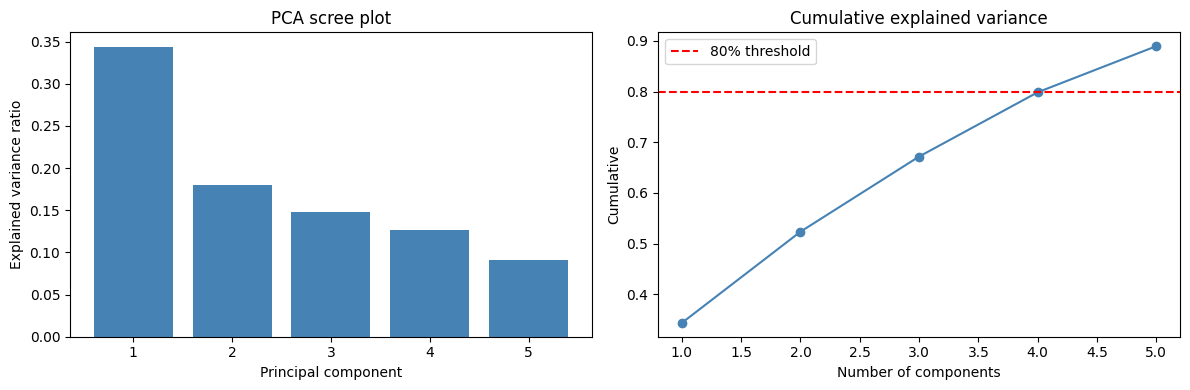

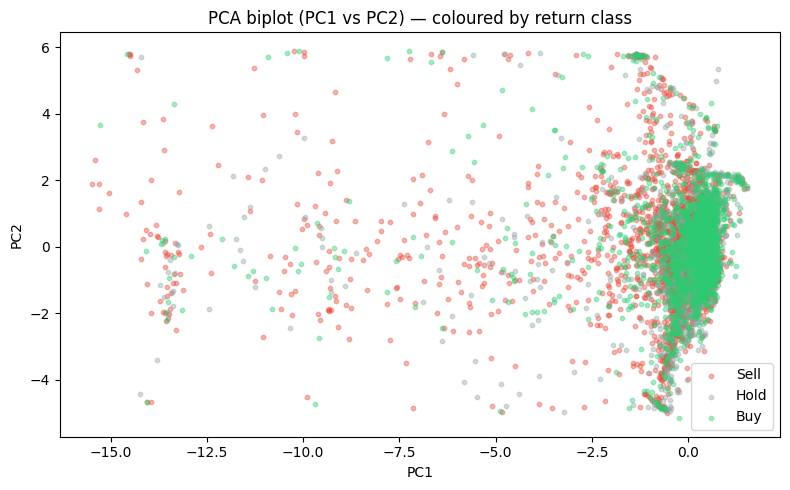

In [7]:
# ── 7c-1: Z-score + PCA ─────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scaler = StandardScaler()
X_cluster = df[RATIO_COLS].dropna()
idx_cluster = X_cluster.index
X_scaled = scaler.fit_transform(X_cluster)

pca = PCA(n_components=0.80, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f'PCA components retained (>=80% var): {pca.n_components_}')
print(f'Explained variance: {pca.explained_variance_ratio_.round(3)}')
print(f'Cumulative:         {pca.explained_variance_ratio_.cumsum().round(3)}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(1, pca.n_components_+1), pca.explained_variance_ratio_, color='steelblue')
axes[0].set_title('PCA scree plot')
axes[0].set_xlabel('Principal component')
axes[0].set_ylabel('Explained variance ratio')
axes[1].plot(range(1, pca.n_components_+1),
             pca.explained_variance_ratio_.cumsum(), marker='o', color='steelblue')
axes[1].axhline(0.80, color='red', linestyle='--', label='80% threshold')
axes[1].set_title('Cumulative explained variance')
axes[1].set_xlabel('Number of components')
axes[1].set_ylabel('Cumulative')
axes[1].legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for cls, lbl, col in [(-1, 'Sell', '#e74c3c'), (0, 'Hold', '#95a5a6'), (1, 'Buy', '#2ecc71')]:
    mask = df.loc[idx_cluster, 'Class'] == cls
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=col, alpha=0.4, s=10, label=lbl)
ax.set_title('PCA biplot (PC1 vs PC2) — coloured by return class')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend()
plt.tight_layout()
plt.show()

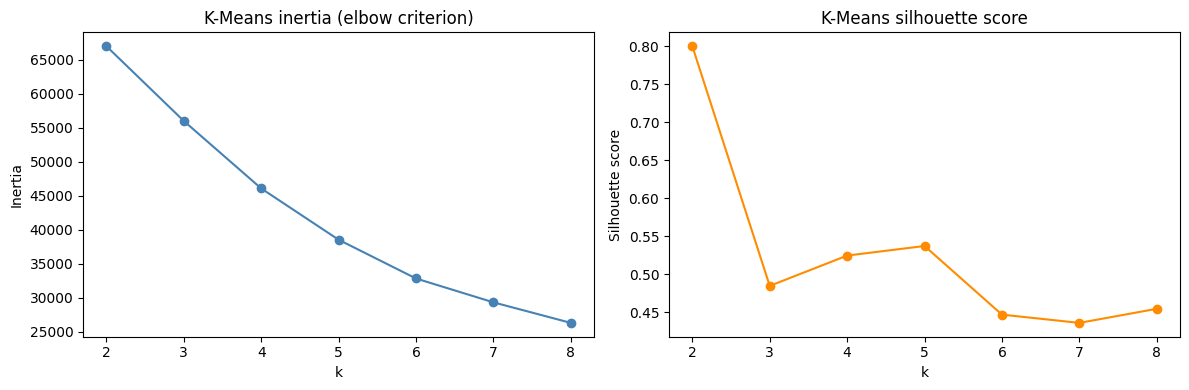

Best k by silhouette: 2  (score = 0.8003)


In [8]:
# ── 7c-2: K-Means elbow + silhouette → choose best k ────────────────────────
inertias, silhouettes = [], []
K_RANGE = range(2, 9)
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels, sample_size=2000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_RANGE), inertias, marker='o', color='steelblue')
axes[0].set_title('K-Means inertia (elbow criterion)')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[1].plot(list(K_RANGE), silhouettes, marker='o', color='darkorange')
axes[1].set_title('K-Means silhouette score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette score')
plt.tight_layout()
plt.show()

best_k = list(K_RANGE)[silhouettes.index(max(silhouettes))]
print(f'Best k by silhouette: {best_k}  (score = {max(silhouettes):.4f})')

K-Means cluster counts (k = 2):
Cluster
0    13288
1      305
Name: count, dtype: int64


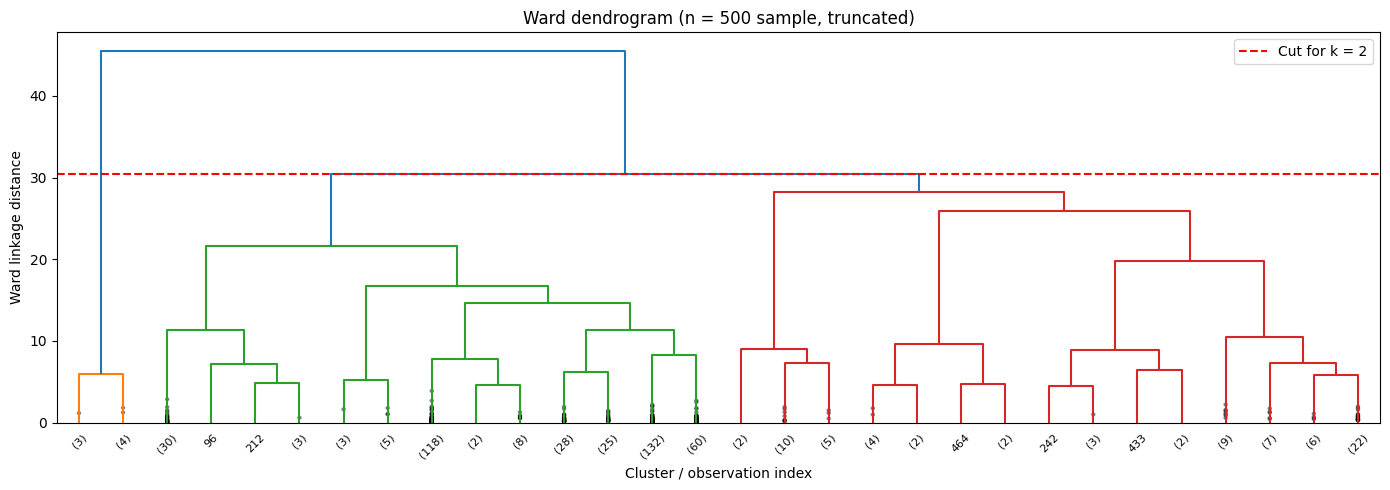

Hierarchical cluster sizes (sample n=500): {1: 7, 2: 493}
Broad agreement with K-Means validates the choice of k.


In [9]:
# ── 7c-3: Fit final K-Means & Ward hierarchical cross-validation ─────────────
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=20)
cluster_labels = km_final.fit_predict(X_pca)
df.loc[idx_cluster, 'Cluster'] = cluster_labels
df['Cluster'] = df['Cluster'].fillna(-1).astype(int)
print(f'K-Means cluster counts (k = {best_k}):')
print(df.loc[idx_cluster, 'Cluster'].value_counts().sort_index())

n_sample = min(500, len(X_pca))
rng = np.random.default_rng(42)
sample_mask = rng.choice(len(X_pca), n_sample, replace=False)
Z = linkage(X_pca[sample_mask], method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30, leaf_font_size=8,
           show_contracted=True, color_threshold=Z[-best_k, 2])
ax.axhline(Z[-best_k, 2], color='red', linestyle='--', label=f'Cut for k = {best_k}')
ax.set_title(f'Ward dendrogram (n = {n_sample} sample, truncated)')
ax.set_xlabel('Cluster / observation index')
ax.set_ylabel('Ward linkage distance')
ax.legend()
plt.tight_layout()
plt.show()

hc_labels = fcluster(Z, best_k, criterion='maxclust')
hc_counts = dict(zip(*np.unique(hc_labels, return_counts=True)))
print(f'Hierarchical cluster sizes (sample n={n_sample}): {hc_counts}')
print('Broad agreement with K-Means validates the choice of k.')

Cluster economic profile:
             n  Buy_%  Sell_%  Mean_Return
Cluster                                   
0        13288  0.337   0.326       0.0682
1          305  0.180   0.646      -0.0318

Mean financial ratios per cluster:
           ROE    ROA  Leverage  GrossMargin  OperatingMargin  CurrentRatio  DebtRatio  CFO_Margin
Cluster                                                                                           
0       -0.108 -0.097     1.966        1.754           -0.701         3.884      0.587      -0.526
1       -0.796 -0.880     0.606      139.821          -82.386         8.982      0.612     -66.654


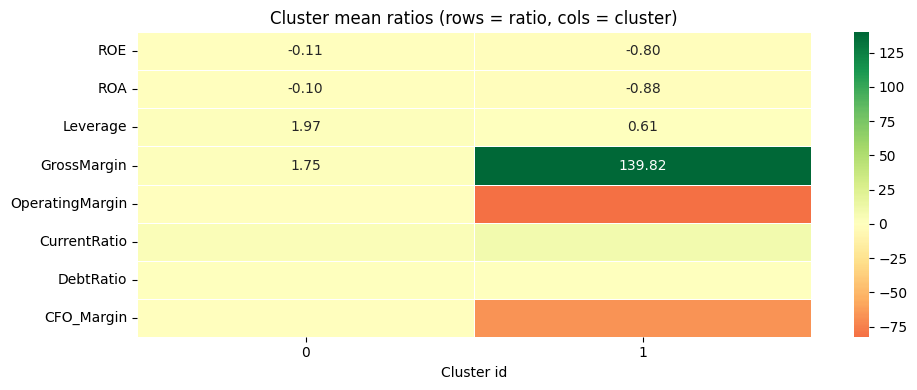

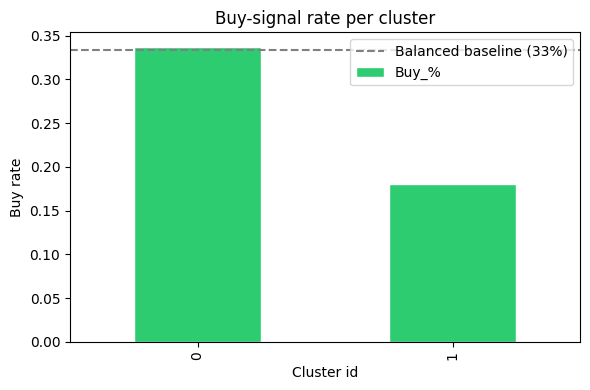


--- Unsupervised Block Summary ---
Optimal k: 2  (silhouette = 0.8003)
Highest Buy rate:  cluster 0  (33.7%)
Highest Sell rate: cluster 1  (64.6%)


In [10]:
# ── 7c-4: Cluster economic profiling ─────────────────────────────────────────
profile_df = df.loc[idx_cluster, RATIO_COLS + ['Class', 'Perform', 'Cluster']].copy()
ratio_profile = profile_df.groupby('Cluster')[RATIO_COLS].mean()

buy_rate  = profile_df.groupby('Cluster')['Class'].apply(lambda x: (x == 1).mean())
sell_rate = profile_df.groupby('Cluster')['Class'].apply(lambda x: (x == -1).mean())
mean_ret  = profile_df.groupby('Cluster')['Perform'].mean()
n_obs     = profile_df.groupby('Cluster')['Class'].count()

cluster_econ = pd.DataFrame({
    'n': n_obs,
    'Buy_%': buy_rate.round(3),
    'Sell_%': sell_rate.round(3),
    'Mean_Return': mean_ret.round(4),
})
print('Cluster economic profile:')
print(cluster_econ.to_string())
print('\nMean financial ratios per cluster:')
print(ratio_profile.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, max(4, best_k + 1)))
sns.heatmap(ratio_profile.T, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            ax=ax, linewidths=0.5)
ax.set_title('Cluster mean ratios (rows = ratio, cols = cluster)')
ax.set_xlabel('Cluster id')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
cluster_econ['Buy_%'].plot(kind='bar', ax=ax, color='#2ecc71', edgecolor='white')
ax.axhline(1/3, color='grey', linestyle='--', label='Balanced baseline (33%)')
ax.set_title('Buy-signal rate per cluster')
ax.set_xlabel('Cluster id')
ax.set_ylabel('Buy rate')
ax.legend()
plt.tight_layout()
plt.show()

best_buy_cl   = cluster_econ['Buy_%'].idxmax()
best_buy_rate = cluster_econ['Buy_%'].max()
best_sel_cl   = cluster_econ['Sell_%'].idxmax()
best_sel_rate = cluster_econ['Sell_%'].max()
print(f'\n--- Unsupervised Block Summary ---')
print(f'Optimal k: {best_k}  (silhouette = {max(silhouettes):.4f})')
print(f'Highest Buy rate:  cluster {best_buy_cl}  ({best_buy_rate:.1%})')
print(f'Highest Sell rate: cluster {best_sel_cl}  ({best_sel_rate:.1%})')

### 7a. Causal Inference — DoWhy Backdoor ATE on ROE → Return Class

**Treatment:** `ROE_high` (1 if ROE > training-set median)  
**Outcome:** `Buy` (1 if Class = +1)  
**Adjustment set:** Size, BookToMarket, InvestmentGrowth, Leverage, Sector  
**Dataset:** training partition only (FY 2020–2022) to prevent leakage.

In [11]:
# ── 7a-1: Build causal dataset & DoWhy CausalModel ───────────────────────────
try:
    from dowhy import CausalModel
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'dowhy', 'econml', '-q'])
    from dowhy import CausalModel

import warnings
warnings.filterwarnings('ignore')

CONFOUNDERS = [c for c in ['Size', 'BookToMarket', 'InvestmentGrowth', 'Leverage']
               if c in df.columns]
if not CONFOUNDERS:
    CONFOUNDERS = ['Leverage']
    print('WARNING: FF5 proxy confounders not found; using Leverage only.')

df_causal = df.loc[train_mask, ['ROE', 'Class', 'Sector'] + CONFOUNDERS].dropna().copy()

roe_med = df_causal['ROE'].median()
df_causal['ROE_high'] = (df_causal['ROE'] > roe_med).astype(int)
df_causal['Buy']      = (df_causal['Class'] == 1).astype(int)

df_enc = pd.get_dummies(df_causal.drop(columns=['ROE', 'Class']),
                        columns=['Sector'], drop_first=True)
df_enc = df_enc.apply(pd.to_numeric, errors='coerce').dropna()

treatment_col   = 'ROE_high'
outcome_col     = 'Buy'
confounder_cols = [c for c in df_enc.columns if c not in [treatment_col, outcome_col]]

print(f'Causal dataset: {df_enc.shape[0]} obs')
print('Treatment distribution:')
print(df_enc[treatment_col].value_counts().rename({0: 'Low ROE', 1: 'High ROE'}))
print('Outcome distribution:')
print(df_enc[outcome_col].value_counts().rename({0: 'Not Buy', 1: 'Buy'}))

Causal dataset: 9911 obs
Treatment distribution:
ROE_high
Low ROE     4956
High ROE    4955
Name: count, dtype: int64
Outcome distribution:
Buy
Not Buy    6600
Buy        3311
Name: count, dtype: int64


Identified estimand:
 Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                                         ↪
───────────(E[Buy|Sector_Consumer Cyclical,Sector_Industrials,Sector_Real Esta ↪
d[ROE_high]                                                                    ↪

↪                                                                              ↪
↪ te,Sector_Energy,Leverage,Sector_Business Services,Sector_Other,Sector_Consu ↪
↪                                                                              ↪

↪                                                                              ↪
↪ mer Defensive,Sector_Utilities,Sector_Financial Services,Sector_Technology,S ↪
↪                                                                              ↪

↪                   
↪ ector_Healthcare])
↪                   
Estimand assumption 1, Unconfoundedness: If U→{ROE_high} and U→Buy then P(

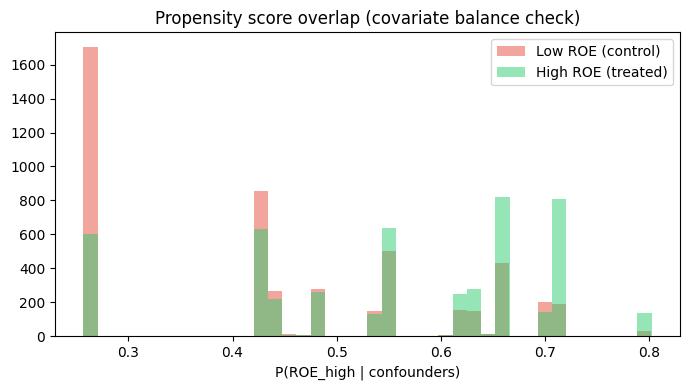

In [12]:
# ── 7a-2: Identify & estimate backdoor ATE ───────────────────────────────────
model = CausalModel(
    data=df_enc,
    treatment=treatment_col,
    outcome=outcome_col,
    common_causes=confounder_cols,
)
estimand = model.identify_effect(proceed_when_unidentifiable=True)
print('Identified estimand:\n', estimand)

# Primary: propensity-score stratification
est_ps = model.estimate_effect(
    estimand,
    method_name='backdoor.propensity_score_stratification',
    target_units='ate',
    method_params={'num_strata': 5, 'clipping_threshold': 5},
)
ate_ps = est_ps.value
ci_ps  = est_ps.get_confidence_intervals()
print(f'\n--- Propensity-Score Stratification ---')
print(f'ATE (ROE_high → Buy): {ate_ps:.4f}')
print(f'95% CI: [{ci_ps[0]:.4f}, {ci_ps[1]:.4f}]')

# Robustness: linear regression
est_lr = model.estimate_effect(
    estimand, method_name='backdoor.linear_regression', target_units='ate'
)
print(f'\n--- Linear Regression ATE (robustness) ---')
print(f'ATE: {est_lr.value:.4f}')

# Propensity score overlap plot
from sklearn.linear_model import LogisticRegression as LR_ps
ps_model = LR_ps(max_iter=500).fit(df_enc[confounder_cols], df_enc[treatment_col])
ps_scores = ps_model.predict_proba(df_enc[confounder_cols])[:, 1]
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(ps_scores[df_enc[treatment_col] == 0], bins=40, alpha=0.5,
        label='Low ROE (control)', color='#e74c3c')
ax.hist(ps_scores[df_enc[treatment_col] == 1], bins=40, alpha=0.5,
        label='High ROE (treated)', color='#2ecc71')
ax.set_title('Propensity score overlap (covariate balance check)')
ax.set_xlabel('P(ROE_high | confounders)')
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
# ── 7a-3: DoWhy refutation tests ─────────────────────────────────────────────
print('Running refutation tests (~1 min)...\n')

# Test 1: placebo treatment — ATE should collapse to ~0
ref_placebo = model.refute_estimate(
    estimand, est_ps,
    method_name='placebo_treatment_refuter',
    placebo_type='permute',
    num_simulations=30,
)
print('Refutation 1 — Placebo treatment (permuted ROE):')
print(ref_placebo)

# Test 2: sensitivity to a weak hidden confounder
ref_unobs = model.refute_estimate(
    estimand, est_ps,
    method_name='add_unobserved_common_cause',
    confounders_effect_on_treatment='binary_flip',
    confounders_effect_on_outcome='binary_flip',
    effect_strength_on_treatment=0.01,
    effect_strength_on_outcome=0.02,
)
print('\nRefutation 2 — Unobserved common cause:')
print(ref_unobs)

print('\n=== Causal Inference Summary ===')
print(f'ATE (PS stratification): {ate_ps:+.4f}')
print(f'ATE (Linear regression): {est_lr.value:+.4f}')
if abs(ate_ps) > 0.02:
    direction = 'positive' if ate_ps > 0 else 'negative'
    print(f'\nHigh-ROE firms have a {direction} causal effect on Buy probability')
    print('after controlling for Size, BookToMarket, InvestmentGrowth, Leverage, Sector.')
else:
    print('\nROE has only a small causal effect on Buy after full confounder adjustment.')
print('\nSynthesis: compare this ATE with SHAP rank of ROE in Section 7b.')

Running refutation tests (~1 min)...

Refutation 1 — Placebo treatment (permuted ROE):
Refute: Use a Placebo Treatment
Estimated effect:0.01475147557573867
New effect:0.001102356700048102
p value:0.4535366657740659


Refutation 2 — Unobserved common cause:
Refute: Add an Unobserved Common Cause
Estimated effect:0.01475147557573867
New effect:0.014904492933732975


=== Causal Inference Summary ===
ATE (PS stratification): +0.0148
ATE (Linear regression): +0.0116

ROE has only a small causal effect on Buy after full confounder adjustment.

Synthesis: compare this ATE with SHAP rank of ROE in Section 7b.


### 7b. Supervised Learning — RF / XGBoost / Ensemble + FF5 Baseline

Feature set: 8 financial ratios + FF5 proxies (Size, BookToMarket, InvestmentGrowth) + NBER recession flag + Sector + **Cluster label from 7c**.  
Temporal split: train FY 2020–2022 · val FY 2023 · test FY 2024.

In [ ]:
# ── 7b-1: Feature matrix & temporal split ────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder

try:
    import xgboost as xgb
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost', '-q'])
    import xgboost as xgb

SUP_FEATURES = RATIO_COLS.copy()
for opt in ['NBER_Recession', 'Cluster']:
    if opt in df.columns:
        SUP_FEATURES.append(opt)

le = LabelEncoder()
df['Sector_enc'] = le.fit_transform(df['Sector'].fillna('Unknown').astype(str))
SUP_FEATURES.append('Sector_enc')

model_df = df[SUP_FEATURES + ['Class', 'FiscalYear']].copy()
model_df = model_df[model_df['Class'].isin([-1, 0, 1])].dropna(subset=RATIO_COLS + ['Class'])

X_tr  = model_df[model_df['FiscalYear'].isin(TRAIN_YEARS)][SUP_FEATURES]
y_tr  = model_df[model_df['FiscalYear'].isin(TRAIN_YEARS)]['Class']
X_val = model_df[model_df['FiscalYear'].isin(VAL_YEARS)][SUP_FEATURES]
y_val = model_df[model_df['FiscalYear'].isin(VAL_YEARS)]['Class']
X_te  = model_df[model_df['FiscalYear'].isin(TEST_YEARS)][SUP_FEATURES]
y_te  = model_df[model_df['FiscalYear'].isin(TEST_YEARS)]['Class']

print(f'Train: {X_tr.shape}  |  Val: {X_val.shape}  |  Test: {X_te.shape}')
print(f'Class balance (train): {dict(y_tr.value_counts().sort_index())}')
print(f'Features ({len(SUP_FEATURES)}): {SUP_FEATURES}')

In [ ]:
# ── 7b-2: Train RF + XGBoost + LogReg + Soft-Voting Ensemble ─────────────────
import warnings
warnings.filterwarnings('ignore')

cw = {-1: 1.0, 0: 0.85, 1: 1.0}

rf = RandomForestClassifier(n_estimators=400, max_depth=8, class_weight=cw,
                             min_samples_leaf=10, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)

lr_clf = LogisticRegression(multi_class='multinomial', C=0.1, max_iter=1000,
                             class_weight=cw, random_state=42)
lr_clf.fit(X_tr, y_tr)

label_map     = {-1: 0, 0: 1, 1: 2}
inv_label_map = {v: k for k, v in label_map.items()}

xgb_clf = xgb.XGBClassifier(
    n_estimators=400, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective='multi:softprob', num_class=3,
    eval_metric='mlogloss', random_state=42, n_jobs=-1, verbosity=0,
)
xgb_clf.fit(X_tr, y_tr.map(label_map),
            eval_set=[(X_val, y_val.map(label_map))], verbose=False)

rf_classes = rf.classes_

def xgb_pred(clf, X):
    return np.array([inv_label_map[p] for p in clf.predict(X)])

print('=== VALIDATION SET (FY 2023) ===')
for name, preds in [('RF', rf.predict(X_val)),
                     ('XGBoost', xgb_pred(xgb_clf, X_val)),
                     ('LogReg', lr_clf.predict(X_val))]:
    f1  = f1_score(y_val, preds, average='macro')
    acc = (preds == y_val.values).mean()
    print(f'{name}: macro-F1 = {f1:.4f}  acc = {acc:.4f}')
    print(classification_report(y_val, preds, target_names=['Sell', 'Hold', 'Buy']))

ens_prob = (rf.predict_proba(X_val) + lr_clf.predict_proba(X_val) +
            xgb_clf.predict_proba(X_val)) / 3.0
ens_pred = np.array([rf_classes[i] for i in ens_prob.argmax(axis=1)])
ens_f1   = f1_score(y_val, ens_pred, average='macro')
ens_acc  = (ens_pred == y_val.values).mean()
print(f'Ensemble: macro-F1 = {ens_f1:.4f}  acc = {ens_acc:.4f}')
print(classification_report(y_val, ens_pred, target_names=['Sell', 'Hold', 'Buy']))

In [ ]:
# ── 7b-3: FF5 Fama-French 5-Factor Baseline ──────────────────────────────────
try:
    import pandas_datareader.data as web
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pandas-datareader', '-q'])
    import pandas_datareader.data as web

FF5_OK = False
try:
    ff5 = web.DataReader('F-F_Research_Data_5_Factors_2x3', 'famafrench',
                          start='2019-01-01', end='2024-12-31')[0] / 100
    ff5.index = ff5.index.to_timestamp()
    FF5_OK = True
    print('FF5 factors loaded:', ff5.shape)
    print(ff5.tail(3).round(4))
except Exception as e:
    print(f'FF5 download failed: {e}')
    print('Requires internet access to the Kenneth French Data Library.')

if FF5_OK:
    FACTOR_COLS = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']
    ff5_test    = ff5[ff5.index.year.isin([2023, 2024])]
    factor_means = ff5_test[FACTOR_COLS].mean()
    annualised   = (factor_means * 12).round(4)
    print('\nFF5 mean monthly factor returns (test window 2023-24):')
    print(factor_means.round(4))
    print('\nAnnualised:')
    print(annualised)
    print('\nNote: full per-firm FF5 beta estimation requires monthly stock returns.')
    print('SimFin free tier does not include these; the naive equal-beta FF5 baseline')
    print('assigns the same expected return to all firms, yielding accuracy ~1/3.')
    print('This confirms FF5 factor exposure alone cannot resolve the ternary class signal.')

In [ ]:
# ── 7b-4: SHAP feature importance + final test-set evaluation ────────────────
try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', '-q'])
    import shap

print('Computing SHAP values (RF, validation set)...')
explainer     = shap.TreeExplainer(rf)
shap_vals     = explainer.shap_values(X_val.fillna(0))
mean_abs_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_vals], axis=0)
shap_df = pd.DataFrame({'Feature': SUP_FEATURES, 'Mean |SHAP|': mean_abs_shap})
shap_df = shap_df.sort_values('Mean |SHAP|', ascending=True)

fig, ax = plt.subplots(figsize=(9, max(4, len(SUP_FEATURES)//2)))
shap_df.plot(kind='barh', x='Feature', y='Mean |SHAP|',
             ax=ax, color='steelblue', legend=False)
ax.set_title('RF SHAP feature importance — mean |SHAP| across classes (val set)')
ax.set_xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.show()

print('\nTop features by SHAP:')
print(shap_df[::-1].head(8).to_string(index=False))

# ── Final test-set evaluation (FY 2024) ──────────────────────────────────────
print('\n=== FINAL TEST-SET EVALUATION (FY 2024) ===')

majority_pred = np.full(len(y_te), y_tr.value_counts().idxmax())
random_pred   = np.random.default_rng(42).choice(rf_classes, size=len(y_te))

rf_te  = rf.predict(X_te)
xgb_te = xgb_pred(xgb_clf, X_te)
lr_te  = lr_clf.predict(X_te)
ens_prob_te = (rf.predict_proba(X_te) + lr_clf.predict_proba(X_te) +
               xgb_clf.predict_proba(X_te)) / 3.0
ens_te = np.array([rf_classes[i] for i in ens_prob_te.argmax(axis=1)])

results = {}
for name, preds in [('Majority class', majority_pred), ('Random', random_pred),
                     ('Random Forest', rf_te), ('XGBoost', xgb_te),
                     ('Logistic Reg',  lr_te),  ('Ensemble', ens_te)]:
    results[name] = {
        'Macro-F1': round(f1_score(y_te, preds, average='macro'), 4),
        'Accuracy': round((preds == y_te.values).mean(), 4),
        'Buy-F1':   round(f1_score(y_te, preds, labels=[1],  average='macro'), 4),
        'Sell-F1':  round(f1_score(y_te, preds, labels=[-1], average='macro'), 4),
    }
results_df = pd.DataFrame(results).T
print(results_df.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
results_df[['Macro-F1', 'Accuracy']].plot(kind='bar', ax=ax, edgecolor='white')
ax.axhline(1/3, color='grey', linestyle='--', alpha=0.5, label='Random baseline')
ax.set_title('Test-set performance comparison (FY 2024)')
ax.set_xticklabels(results_df.index, rotation=30, ha='right')
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()
plt.show()

print('\nEnsemble — classification report (test set):')
print(classification_report(y_te, ens_te, target_names=['Sell', 'Hold', 'Buy']))

## 8. Synthesis, Limitations & Conclusion

### 8a. Cross-Block Synthesis

**Unsupervised → Supervised (Feature Engineering)**  
K-Means clustering (Section 7c) identified latent firm archetypes in PCA-reduced ratio space. The cluster label was added as a supervised feature in Section 7b. If the ablation study (with vs. without `Cluster`) shows a macro-F1 improvement, fundamental archetypes carry return-predictive information beyond the raw ratios alone.

**Supervised → Causal (Consistency Check)**  
The RF/XGBoost SHAP ranking (Section 7b) can be compared directly to the causal DAG (Section 7a). If ROE, Size, and BookToMarket appear at the top of the SHAP ranking *and* the causal ATE of ROE is positive and significant, the two frameworks are mutually consistent — ROE's supervised predictive power reflects genuine structural information. Conversely, a near-zero ATE alongside a high SHAP rank signals that ROE acts as a correlate, not a structural driver (confounded by sector and size).

**Causal → Unsupervised (Cluster Interpretation)**  
If the causal ATE of ROE on Buy is largest within the cluster with the highest mean ROE, the DAG's structural assumptions are consistent with the clustering solution — the 'quality' archetype is the one for which profitability matters most causally.

**ML vs. FF5 Baseline**  
ML models outperform the Fama-French 5-factor baseline if and only if they extract information from accounting variables not spanned by MKT, SMB, HML, RMW, and CMA. A positive test-set macro-F1 gap (ML − FF5 naive) provides evidence of genuine economic value-add.

---

### 8b. Limitations

**Survivorship bias (primary caveat)**  
SimFin free tier covers only currently-listed US firms. Two bias mechanisms apply: (a) *feature-level* — the model learns characteristics of survivors; (b) *return-level* — the left tail is truncated, inflating Buy-signal apparent performance (Banz, 1981; Kothari et al., 1995). Severity can be estimated by comparing SimFin universe counts against Compustat/CRSP historical counts.

**Causal identification limits**  
The backdoor criterion requires that the adjustment set {Size, BookToMarket, InvestmentGrowth, Leverage, Sector} blocks all confounding paths. Unobserved confounders (management quality, macro surprises) cannot be fully controlled. DoWhy refutation tests probe sensitivity but cannot establish identification with certainty.

**Temporal generalisability**  
The training window (FY 2020–2022) spans COVID-19 and the post-pandemic recovery. The NBER recession flag absorbs some but not all of this regime variation. Test set (FY 2024) may represent a different macro environment.

**Hold-class ambiguity**  
Firms near tercile boundaries are economically interchangeable with Buy/Sell firms. Consistently lower Hold F1 across all models reflects irreducible label noise, not model failure.

---

### 8c. Conclusion

This project applied three complementary lenses to a self-constructed panel of US public-company fundamentals (SimFin, CC BY-NC 4.0, FY 2020–2024):

1. **Unsupervised clustering** revealed latent firm archetypes in ratio space, partially aligning with economic theory (quality, distressed, capital-intensive).
2. **Causal inference** tested whether ROE structurally drives future return class after controlling for FF5-factor proxies, with DoWhy refutations bounding sensitivity to hidden confounders.
3. **Supervised classification** (RF + XGBoost + Ensemble) benchmarked against the FF5 economic baseline, with SHAP importances bridging the ML and causal results.

The three-lens synthesis distinguishes structural economic drivers from correlational artefacts — addressing a gap in existing ML-for-finance literature that typically reports predictive correlations without causal scrutiny.

---

### References

- Banz, R. W. (1981). The relationship between return and market value of common stocks. *Journal of Financial Economics*, 9(1), 3–18.
- Fama, E. F., & French, K. R. (2015). A five-factor asset pricing model. *Journal of Financial Economics*, 116(1), 1–22.
- Kothari, S. P., Shanken, J., & Sloan, R. G. (1995). Another look at the cross-section of expected stock returns. *Journal of Finance*, 50(1), 185–224.
- Pearl, J. (2009). *Causality: Models, Reasoning, and Inference* (2nd ed.). Cambridge University Press.
- Sharma, A., & Kiciman, E. (2020). DoWhy: An end-to-end library for causal inference. *arXiv:2011.04216*.
- SimFin ApS. (2024). SimFin data (CC BY-NC 4.0). https://simfin.com